# Data Loading and Preparation

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('data.csv')

In [31]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [32]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

# Class Naming and Label Encoding

In [33]:
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


In [34]:
y = df['diagnosis'].values


In [35]:
X = df.drop(columns=['diagnosis']).values


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(455, 30)
(114, 30)
(455,)
(114,)


In [38]:
X_train.shape[0]/X.shape[0]

0.7996485061511424

In [39]:
X.shape[0]

569

# Data Normalization

In [41]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN implementation from scratch

In [42]:
from sklearn.metrics import classification_report

class KNNClassifierScratch:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _calculate_distance(self, x1, x2):
        if self.metric == 'Euclidean Distance':
            return np.sqrt(np.sum((x1 - x2) ** 2))

        elif self.metric == 'Manhattan Distance':
            return np.sum(np.abs(x1 - x2))

        elif self.metric == 'Minkowski Distance':
            return np.sum(np.abs(x1 - x2) ** 3) ** (1/3)

        elif self.metric == 'Cosine Distance':
            dot = np.dot(x1, x2)
            norm_x1 = np.linalg.norm(x1)
            norm_x2 = np.linalg.norm(x2)
            similarity = dot / (norm_x1 * norm_x2 + 1e-8)
            return 1 - similarity

        elif self.metric == 'Hamming Distance':
            return np.sum(x1 != x2)
        return 0

    def predict(self, X_test):
        predictions = []

        for test_row in X_test:
            distances = []
            for train_row in self.X_train:
                d = self._calculate_distance(test_row, train_row)
                distances.append(d)

            sorted_pairs = sorted(zip(distances, self.y_train))
            k_nearest_labels = [label for dist, label in sorted_pairs[:self.k]]
            votes_for_1 = k_nearest_labels.count(1)
            votes_for_0 = k_nearest_labels.count(0)

            if votes_for_1 > votes_for_0:
                predictions.append(1)
            else:
                predictions.append(0)

        return np.array(predictions)


# KNN Experiments with Different K Values and Distance Metrics

In [43]:
k_values = [3, 4, 9, 20, 47]

metrics = [
    'Euclidean Distance',
    'Manhattan Distance',
    'Minkowski Distance',
    'Cosine Distance',
    'Hamming Distance'
]

accuracy_records = {metric: [] for metric in metrics}

best_accuracy = 0
best_k = 0
best_metric = ""

for metric in metrics:

    for k in k_values:

        model = KNNClassifierScratch(k=k, metric=metric)

        # Use scaled training data
        model.fit(X_train_scaled, y_train)

        # Use scaled test data
        preds = model.predict(X_test_scaled)

        accuracy = np.mean(preds == y_test)

        accuracy_records[metric].append(accuracy)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_metric = metric

print(f"Winner Configuration: K = {best_k} using {best_metric}")
print(f"Max Accuracy Achieved: {best_accuracy * 100:.2f}%")

Winner Configuration: K = 9 using Euclidean Distance
Max Accuracy Achieved: 96.49%


# Evaluation of the Model Using Different Metrics

In [44]:
final_model = KNNClassifierScratch(k=best_k, metric=best_metric)

final_model.fit(X_train_scaled, y_train)

final_preds = final_model.predict(X_test_scaled)


TP = np.sum((y_test == 1) & (final_preds == 1))
FP = np.sum((y_test == 0) & (final_preds == 1))
TN = np.sum((y_test == 0) & (final_preds == 0))
FN = np.sum((y_test == 1) & (final_preds == 0))


precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0


print(f"Confusion Matrix:\n   [TN: {TN}  FP: {FP}]\n   [FN: {FN}  TP: {TP}]")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score:    {recall:.4f}\n")

Confusion Matrix:
   [TN: 69  FP: 2]
   [FN: 2  TP: 41]
Precision Score: 0.9535
Recall Score:    0.9535



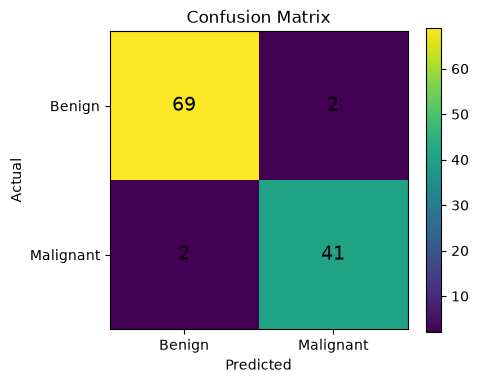

In [45]:
cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(5, 4))

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Benign", "Malignant"])
plt.yticks([0, 1], ["Benign", "Malignant"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.tight_layout()
plt.show()

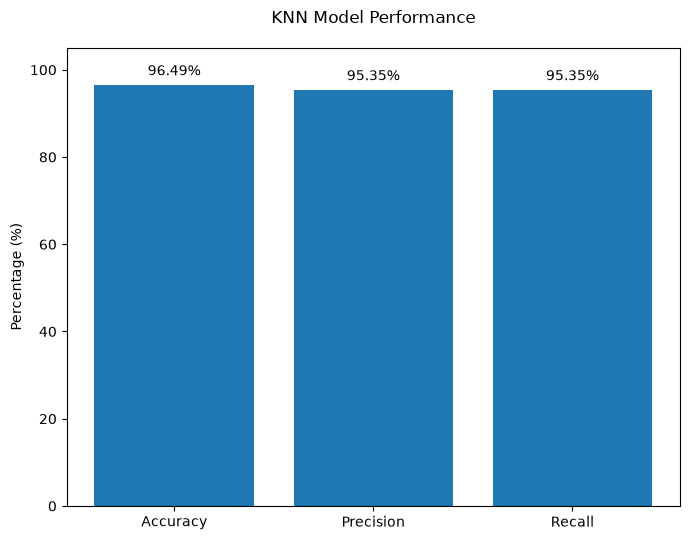

In [46]:
Emetrics = ['Accuracy', 'Precision', 'Recall']
values = [96.49, 95.35, 95.35]

plt.figure(figsize=(7, 5.5))

bars = plt.bar(Emetrics, values)

plt.ylim(0, 105)
plt.ylabel('Percentage (%)')
plt.title('KNN Model Performance', pad=18)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()

plt.savefig(
    'knn_performance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# KNN Model Performance and Decision Boundary Visualization

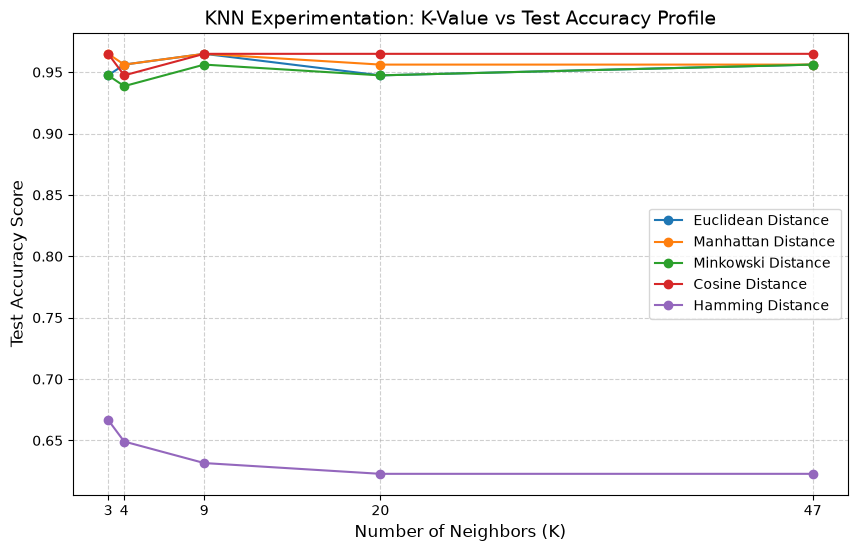

In [47]:

plt.figure(figsize=(10, 6))
for metric in metrics:
    plt.plot(k_values, accuracy_records[metric], marker='o', label=metric)

plt.title('KNN Experimentation: K-Value vs Test Accuracy Profile', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Test Accuracy Score', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

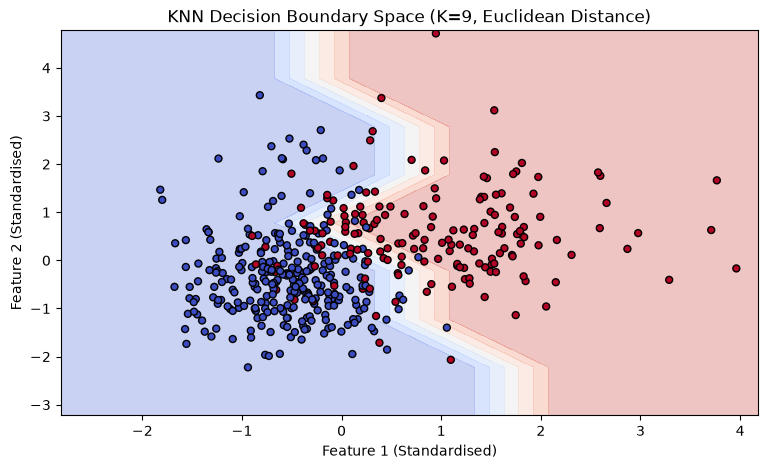

In [48]:

X_train_2d = X_train_scaled[:, :2]

boundary_model = KNNClassifierScratch(k=best_k, metric=best_metric)
boundary_model.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 1.0), np.arange(y_min, y_max, 1.0))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = boundary_model.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(9, 5))
plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k', cmap='coolwarm', s=25)

plt.title(f'KNN Decision Boundary Space (K={best_k}, {best_metric})')
plt.xlabel('Feature 1 (Standardised)')
plt.ylabel('Feature 2 (Standardised)')
plt.show()
